# Stage 2: ResNet-20 Student with Hard Labels≥

## 1. Imports

In [1]:
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import MultiStepLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.cuda.amp import autocast, GradScaler

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration

In [2]:
KAGGLE_WORKING = Path("/kaggle/working")
BASE_OUTPUT_DIR = KAGGLE_WORKING if KAGGLE_WORKING.exists() else Path.cwd() / "outputs"

CONFIG = {
    "model": "resnet20",
    "dataset": "CIFAR100",
    "num_classes": 100,
    "epochs": 200,
    "batch_size": 128,
    "optimizer": "SGD",
    "learning_rate": 0.1,
    "momentum": 0.9,
    "weight_decay": 0.0005,
    "scheduler": "MultiStepLR",
    "milestones": [100, 150],
    "gamma": 0.1,
    "loss": "CrossEntropyLoss",
    "seed": 42,
    "mixed_precision": True,
    "num_workers": 2,
    "pin_memory": True,
    "quick_sanity_check": False,
    "sanity_epochs": 1,
    "output_root": str(BASE_OUTPUT_DIR / "kd_cifar100_artifacts"),
    "stage_dir": "student_resnet20_ce",
}

if CONFIG["quick_sanity_check"]:
    CONFIG["epochs"] = CONFIG["sanity_epochs"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
CONFIG

Using device: cuda


{'model': 'resnet20',
 'dataset': 'CIFAR100',
 'num_classes': 100,
 'epochs': 200,
 'batch_size': 128,
 'optimizer': 'SGD',
 'learning_rate': 0.1,
 'momentum': 0.9,
 'weight_decay': 0.0005,
 'scheduler': 'MultiStepLR',
 'milestones': [100, 150],
 'gamma': 0.1,
 'loss': 'CrossEntropyLoss',
 'seed': 42,
 'mixed_precision': True,
 'num_workers': 2,
 'pin_memory': True,
 'quick_sanity_check': False,
 'sanity_epochs': 1,
 'output_root': '/kaggle/working/kd_cifar100_artifacts',
 'stage_dir': 'student_resnet20_ce'}

## 3. Reproducibility and Output Directories

In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


set_seed(CONFIG["seed"])

stage_root = Path(CONFIG["output_root"]) / CONFIG["stage_dir"]
checkpoint_dir = stage_root / "checkpoints"
log_dir = stage_root / "logs"
config_dir = stage_root / "config"
plot_dir = stage_root / "plots"

for directory in [checkpoint_dir, log_dir, config_dir, plot_dir]:
    directory.mkdir(parents=True, exist_ok=True)

config_path = config_dir / "student_resnet20_ce_config.json"
with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=4)

print(f"Artifacts directory: {stage_root}")
print(f"Saved config: {config_path}")

Artifacts directory: /kaggle/working/kd_cifar100_artifacts/student_resnet20_ce
Saved config: /kaggle/working/kd_cifar100_artifacts/student_resnet20_ce/config/student_resnet20_ce_config.json


## 4. CIFAR-100 Dataset and DataLoaders

In [4]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

data_root = KAGGLE_WORKING / "data" if KAGGLE_WORKING.exists() else Path("./data")
download_dataset = True

train_dataset = datasets.CIFAR100(
    root=str(data_root),
    train=True,
    download=download_dataset,
    transform=train_transform,
)

test_dataset = datasets.CIFAR100(
    root=str(data_root),
    train=False,
    download=download_dataset,
    transform=test_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"] and torch.cuda.is_available(),
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"] and torch.cuda.is_available(),
    drop_last=False,
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {len(train_dataset.classes)}")

100%|██████████| 169M/169M [05:37<00:00, 501kB/s] 


Train samples: 50000
Test samples: 10000
Classes: 100


## 5. CIFAR-Style ResNet Implementation

This is the CIFAR variant: 3x3 initial convolution, no 7x7 convolution, no initial max pooling, and depth formula `6n + 2`. For ResNet-20, `n = 3`.

In [5]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(
            planes, planes, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)

        if stride != 1 or in_planes != planes * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_planes,
                    planes * self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(planes * self.expansion),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = F.relu(out, inplace=True)
        return out


class CIFARResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=100):
        super().__init__()
        self.in_planes = 16

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64 * block.expansion, num_classes)

        self._initialize_weights()

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for block_stride in strides:
            layers.append(block(self.in_planes, planes, block_stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out


def resnet20(num_classes=100):
    return CIFARResNet(BasicBlock, [3, 3, 3], num_classes=num_classes)


def resnet110(num_classes=100):
    return CIFARResNet(BasicBlock, [18, 18, 18], num_classes=num_classes)

## 6. Initialize Student, Loss, Optimizer, and Scheduler

In [6]:
model = resnet20(num_classes=CONFIG["num_classes"]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    momentum=CONFIG["momentum"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = MultiStepLR(
    optimizer,
    milestones=CONFIG["milestones"],
    gamma=CONFIG["gamma"],
)
scaler = GradScaler(enabled=CONFIG["mixed_precision"] and torch.cuda.is_available())

num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {CONFIG['model']}")
print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {num_trainable:,}")

Model: resnet20
Total parameters: 278,324
Trainable parameters: 278,324


/tmp/ipykernel_57/1732656314.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CONFIG["mixed_precision"] and torch.cuda.is_available())


## 7. Training, Evaluation, and Checkpoint Utilities

In [7]:
def accuracy_from_logits(logits, labels):
    predictions = logits.argmax(dim=1)
    correct = predictions.eq(labels).sum().item()
    return correct


def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=CONFIG["mixed_precision"] and torch.cuda.is_available()):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_correct += accuracy_from_logits(logits, labels)
        running_total += batch_size

    epoch_loss = running_loss / running_total
    epoch_acc = 100.0 * running_correct / running_total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_correct += accuracy_from_logits(logits, labels)
        running_total += batch_size

    epoch_loss = running_loss / running_total
    epoch_acc = 100.0 * running_correct / running_total
    return epoch_loss, epoch_acc


def save_checkpoint(path, epoch, model, optimizer, scheduler, best_acc, config, train_dataset):
    checkpoint = {
        "epoch": epoch,
        "model_name": config["model"],
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_acc": best_acc,
        "config": config,
        "class_to_idx": train_dataset.class_to_idx,
        "classes": train_dataset.classes,
    }
    torch.save(checkpoint, path)


def save_log(log_records, path):
    pd.DataFrame(log_records).to_csv(path, index=False)


def plot_training_curves(log_df, plot_dir):
    plt.figure(figsize=(8, 5))
    plt.plot(log_df["epoch"], log_df["train_acc"], label="Train Accuracy")
    plt.plot(log_df["epoch"], log_df["test_acc"], label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("ResNet-20 CE Student Accuracy on CIFAR-100")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / "student_ce_accuracy_curve.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(log_df["epoch"], log_df["train_loss"], label="Train Loss")
    plt.plot(log_df["epoch"], log_df["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("ResNet-20 CE Student Loss on CIFAR-100")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / "student_ce_loss_curve.png", dpi=200)
    plt.show()

## 8. Train ResNet-20 Student with Cross Entropy

In [8]:
best_checkpoint_path = checkpoint_dir / "student_resnet20_ce_best.pth"
last_checkpoint_path = checkpoint_dir / "student_resnet20_ce_last.pth"
log_path = log_dir / "student_ce_training_log.csv"

log_records = []
best_acc = 0.0
start_time = time.time()

for epoch in range(1, CONFIG["epochs"] + 1):
    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, device
    )
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]
    is_best = test_acc > best_acc
    if is_best:
        best_acc = test_acc
        save_checkpoint(
            best_checkpoint_path,
            epoch,
            model,
            optimizer,
            scheduler,
            best_acc,
            CONFIG,
            train_dataset,
        )

    save_checkpoint(
        last_checkpoint_path,
        epoch,
        model,
        optimizer,
        scheduler,
        best_acc,
        CONFIG,
        train_dataset,
    )

    epoch_time = time.time() - epoch_start
    record = {
        "epoch": epoch,
        "lr": current_lr,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "best_test_acc": best_acc,
        "epoch_time_sec": epoch_time,
    }
    log_records.append(record)
    save_log(log_records, log_path)

    print(
        f"Epoch {epoch:03d}/{CONFIG['epochs']:03d} | "
        f"lr {current_lr:.5f} | "
        f"train loss {train_loss:.4f}, acc {train_acc:.2f}% | "
        f"test loss {test_loss:.4f}, acc {test_acc:.2f}% | "
        f"best {best_acc:.2f}% | "
        f"time {epoch_time:.1f}s"
    )

total_time = time.time() - start_time
print(f"Training finished in {total_time / 3600:.2f} hours")
print(f"Best test accuracy: {best_acc:.2f}%")

/tmp/ipykernel_57/1158149121.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG["mixed_precision"] and torch.cuda.is_available()):


Epoch 001/200 | lr 0.10000 | train loss 4.0763, acc 7.34% | test loss 3.7101, acc 11.64% | best 11.64% | time 15.2s
Epoch 002/200 | lr 0.10000 | train loss 3.4721, acc 16.31% | test loss 3.3217, acc 20.02% | best 20.02% | time 13.7s
Epoch 003/200 | lr 0.10000 | train loss 3.0572, acc 23.36% | test loss 3.0898, acc 24.16% | best 24.16% | time 13.9s
Epoch 004/200 | lr 0.10000 | train loss 2.7374, acc 29.50% | test loss 3.0718, acc 26.09% | best 26.09% | time 13.6s
Epoch 005/200 | lr 0.10000 | train loss 2.5139, acc 33.87% | test loss 2.6425, acc 31.75% | best 31.75% | time 13.5s
Epoch 006/200 | lr 0.10000 | train loss 2.3365, acc 37.43% | test loss 2.5105, acc 34.92% | best 34.92% | time 13.6s
Epoch 007/200 | lr 0.10000 | train loss 2.1964, acc 41.12% | test loss 2.5298, acc 35.71% | best 35.71% | time 13.8s
Epoch 008/200 | lr 0.10000 | train loss 2.1077, acc 42.68% | test loss 2.4494, acc 36.52% | best 36.52% | time 13.6s
Epoch 009/200 | lr 0.10000 | train loss 2.0229, acc 44.54% | test

## 9. Save Logs and Plots

,epoch,lr,train_loss,train_acc,test_loss,test_acc,best_test_acc,epoch_time_sec
195,196,0.001,0.464955,86.702,1.178423,68.69,69.47,13.515819
196,197,0.001,0.464442,86.550,1.182284,68.37,69.47,13.374740
197,198,0.001,0.461194,86.746,1.172409,68.53,69.47,13.405853
198,199,0.001,0.459177,86.744,1.177499,68.56,69.47,13.390813
199,200,0.001,0.459442,86.676,1.176514,68.53,69.47,13.444862


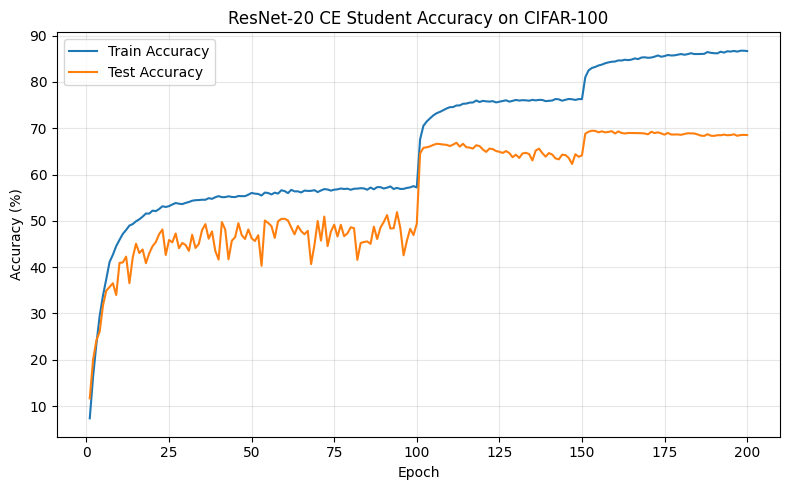

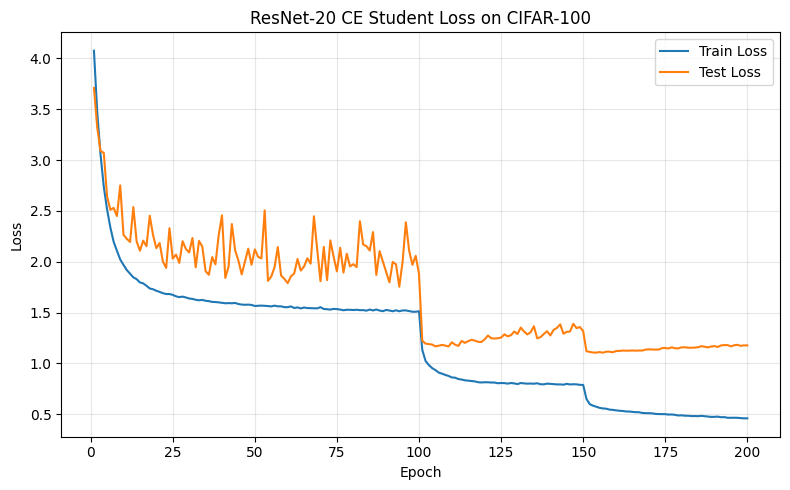

Saved training log: /kaggle/working/kd_cifar100_artifacts/student_resnet20_ce/logs/student_ce_training_log.csv
Saved accuracy plot: /kaggle/working/kd_cifar100_artifacts/student_resnet20_ce/plots/student_ce_accuracy_curve.png
Saved loss plot: /kaggle/working/kd_cifar100_artifacts/student_resnet20_ce/plots/student_ce_loss_curve.png


In [9]:
log_df = pd.DataFrame(log_records)
log_df.to_csv(log_path, index=False)
display(log_df.tail())

plot_training_curves(log_df, plot_dir)

print(f"Saved training log: {log_path}")
print(f"Saved accuracy plot: {plot_dir / 'student_ce_accuracy_curve.png'}")
print(f"Saved loss plot: {plot_dir / 'student_ce_loss_curve.png'}")

## 10. Final Student Baseline Summary

In [10]:
final_record = log_df.iloc[-1].to_dict()
summary = {
    "model": CONFIG["model"],
    "dataset": CONFIG["dataset"],
    "epochs_completed": int(final_record["epoch"]),
    "final_train_accuracy": float(final_record["train_acc"]),
    "final_test_accuracy": float(final_record["test_acc"]),
    "best_test_accuracy": float(final_record["best_test_acc"]),
    "best_checkpoint": str(best_checkpoint_path),
    "last_checkpoint": str(last_checkpoint_path),
    "config_path": str(config_path),
    "log_path": str(log_path),
    "accuracy_plot": str(plot_dir / "student_ce_accuracy_curve.png"),
    "loss_plot": str(plot_dir / "student_ce_loss_curve.png"),
}

summary_path = stage_root / "student_resnet20_ce_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print("Student CE training summary")
for key, value in summary.items():
    print(f"{key}: {value}")

print(f"Saved summary: {summary_path}")

Student CE training summary
model: resnet20
dataset: CIFAR100
epochs_completed: 200
final_train_accuracy: 86.676
final_test_accuracy: 68.53
best_test_accuracy: 69.47
best_checkpoint: /kaggle/working/kd_cifar100_artifacts/student_resnet20_ce/checkpoints/student_resnet20_ce_best.pth
last_checkpoint: /kaggle/working/kd_cifar100_artifacts/student_resnet20_ce/checkpoints/student_resnet20_ce_last.pth
config_path: /kaggle/working/kd_cifar100_artifacts/student_resnet20_ce/config/student_resnet20_ce_config.json
log_path: /kaggle/working/kd_cifar100_artifacts/student_resnet20_ce/logs/student_ce_training_log.csv
accuracy_plot: /kaggle/working/kd_cifar100_artifacts/student_resnet20_ce/plots/student_ce_accuracy_curve.png
loss_plot: /kaggle/working/kd_cifar100_artifacts/student_resnet20_ce/plots/student_ce_loss_curve.png
Saved summary: /kaggle/working/kd_cifar100_artifacts/student_resnet20_ce/student_resnet20_ce_summary.json
